In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.axes as ax

In [7]:
data=pd.read_csv("data_for_lr.csv")

In [9]:
data.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [11]:
data.isnull().sum()

x    0
y    1
dtype: int64

In [13]:
data.dropna(inplace=True)
data.shape

(699, 2)

In [15]:
train_ip=np.array(data.x[0:500]).reshape(500,1)
train_op=np.array(data.y[0:500]).reshape(500,1)

test_ip=np.array(data.x[500:699]).reshape(199,1)
test_op=np.array(data.x[500:700]).reshape(199,1)

In [17]:
test_ip.shape

(199, 1)

# <font color="green">Linear Regression</font>

## Forward Propagation

### f(x)=m*x+c

In [42]:
def forward_propagation(train_ip,parameters):
    m=parameters["m"]
    c=parameters["c"]

    predictions=np.multiply(m,train_ip)+c

    return predictions

## Cost Function

### summation (1/2n* (y-f(x))^2)

In [26]:
def cost_func(prediction,train_op):

    cost=np.mean((train_op-prediction)**2)/2

    return cost

## Gradient Descent for BackPropagation

### df =summ(f(x)-y)/n
### dm=df*x
### dc=df*1

In [30]:
def back_propagation(train_ip,train_op,prediction):
    derivatives=dict()
    
    df=prediction-train_op
    dm=np.mean(np.multiply(df,train_ip))

    dc=np.mean(df)

    derivatives["dm"]=dm
    derivatives["dc"]=dc

    return derivatives

## Update Parameters

#### m=m-(learn_rate*dm)
#### c=c-(learn_rate*dc)

In [34]:
def update_param(parameters,derivatives,learn_rate):
    parameters["m"]=parameters["m"]-learn_rate*derivatives["dm"]
    parameters["c"]=parameters["c"]-learn_rate*derivatives["dc"]

    return parameters

## Model Training

In [77]:
def train(train_ip,train_op,learn_rate,iters ):
    # random parameters
    parameters=dict()
    parameters["m"]=np.random.uniform(0,1)*-1
    parameters["c"]=np.random.uniform(0,1)*-1

    plt.figure()

    #loss
    loss=list()

    #iteration
    for i in range (iters):
    #forward propagation
        prediction=forward_propagation(train_ip,parameters)

    #cost
        cost=cost_func(prediction,train_op)

        loss.append(cost)
        print(f"Iteration ={i+1},Loss={cost}")

        fig,ax=plt.subplots()

        ax.plot(train_ip,train_op,"+",label="Original")
        ax.plot(train_ip,prediction,"*",label="Training")

        legend=ax.legend()

        plt.plot(train_ip,train_op,"+",label="Original")
        plt.plot(train_ip,prediction,"*",label="Training")
        plt.show()

    #back propagation
        derivatives=back_propagation(train_ip,train_op,prediction)

    #update the parameters
        param=update_param(parameters,derivatives,learn_rate)

    return param,loss

## Training

Iteration =1,Loss=3993.118089354752


<Figure size 640x480 with 0 Axes>

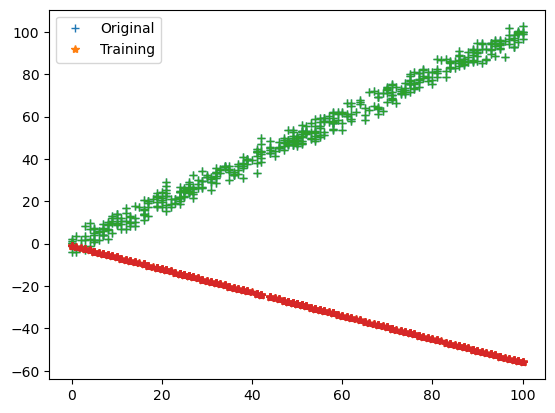

Iteration =2,Loss=1813.8531221099195


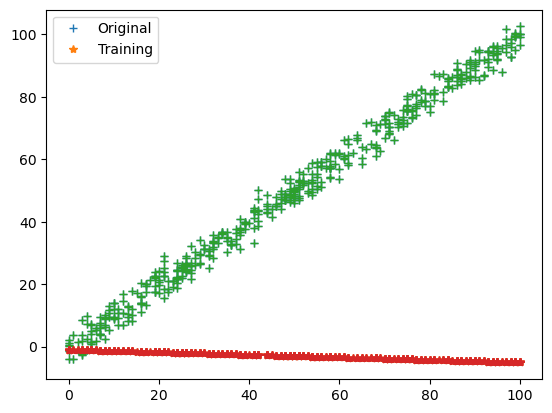

Iteration =3,Loss=825.1181908744284


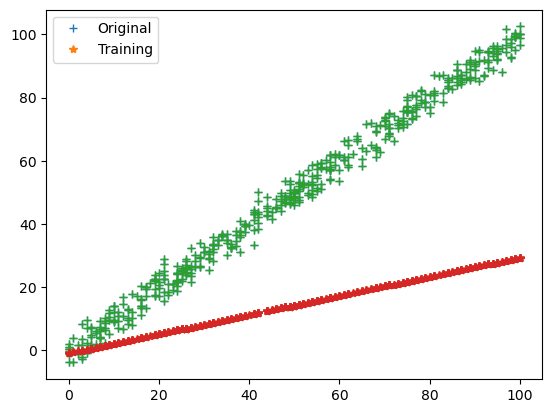

Iteration =4,Loss=376.5280556565982


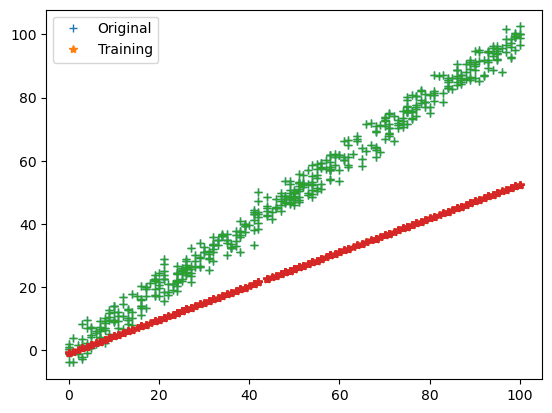

Iteration =5,Loss=173.00221267870722


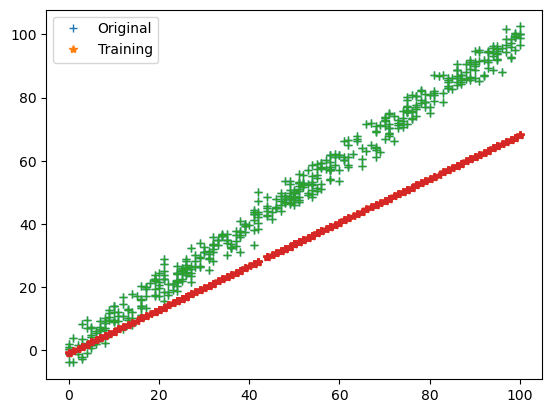

Iteration =6,Loss=80.66231053347471


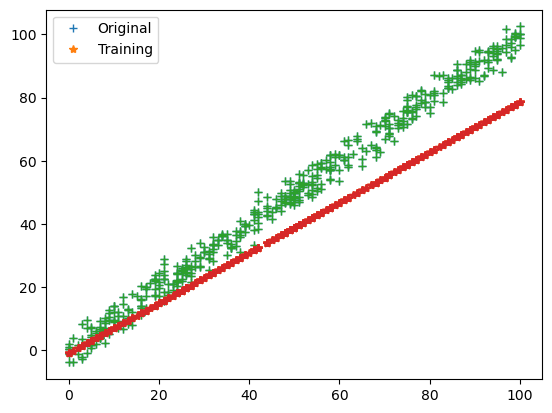

Iteration =7,Loss=38.76759289823829


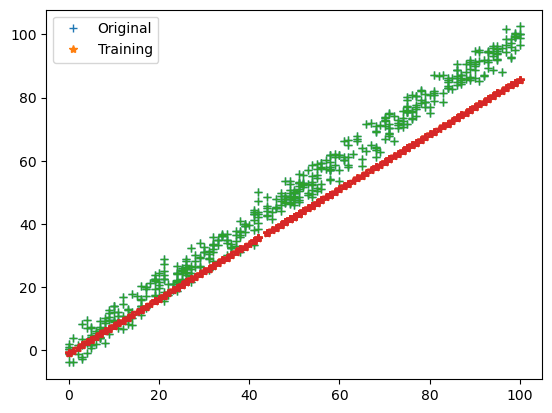

Iteration =8,Loss=19.759911350440767


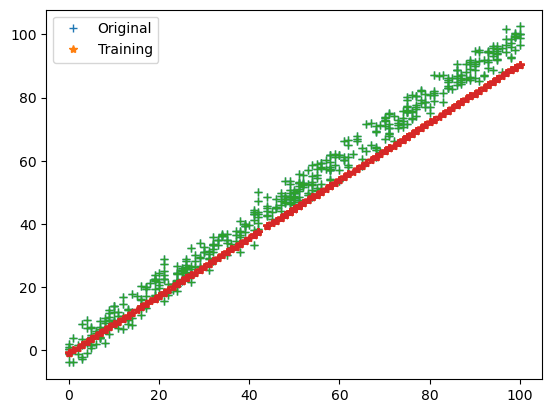

Iteration =9,Loss=11.136103426226986


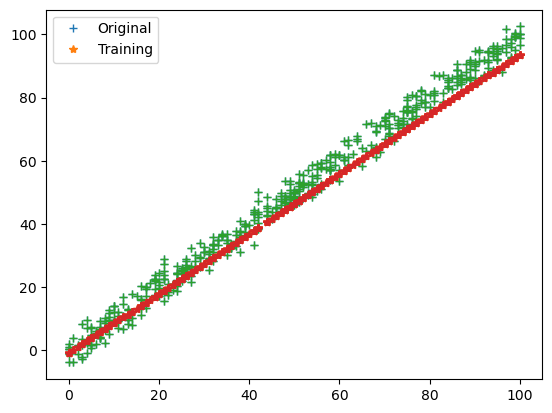

Iteration =10,Loss=7.2234704667277985


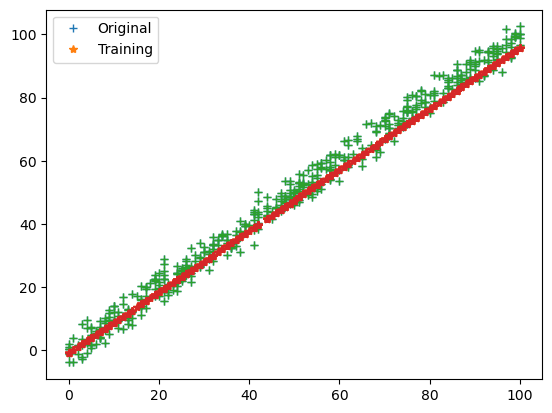

In [80]:
param,loss=train(train_ip,train_op,0.0001,10)

In [82]:
loss

[3993.118089354752,
 1813.8531221099195,
 825.1181908744284,
 376.5280556565982,
 173.00221267870722,
 80.66231053347471,
 38.76759289823829,
 19.759911350440767,
 11.136103426226986,
 7.2234704667277985]

In [84]:
print(param)

{'m': 0.9817128454813817, 'c': -0.9474421828285434}


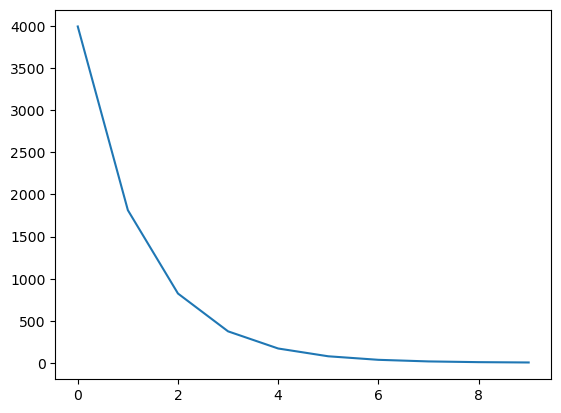

In [96]:
plt.plot(loss)

## Lets Predict

In [88]:
test_predictions=test_ip*param["m"]+param["c"]

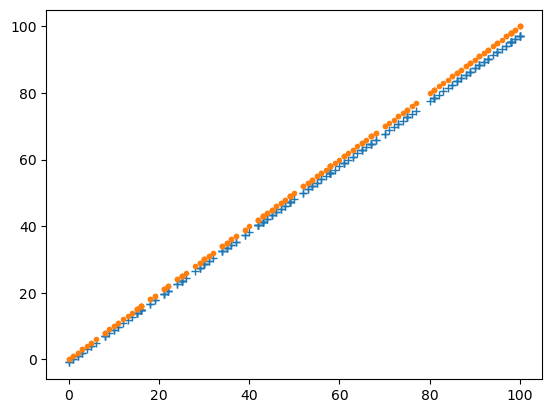

In [99]:
plt.plot(test_ip,test_predictions,"+")
plt.plot(test_ip,test_op,".")
plt.show()

## Cost Of Prediction

In [104]:
cost_func(test_op,test_predictions)

1.931469420381005

## Training Model

In [107]:
from sklearn.linear_model import LinearRegression

In [109]:
lr_model=LinearRegression()

#### All the forward,backward,cost func,parameter updation is done by the fit function

In [111]:
lr_model.fit(train_ip,train_op)

LinearRegression()

In [114]:
lr_model.coef_

array([[1.0009993]])

In [116]:
lr_model.intercept_

array([-0.23603461])

#### Predictions

In [119]:
test_prediction=lr_model.predict(test_ip)

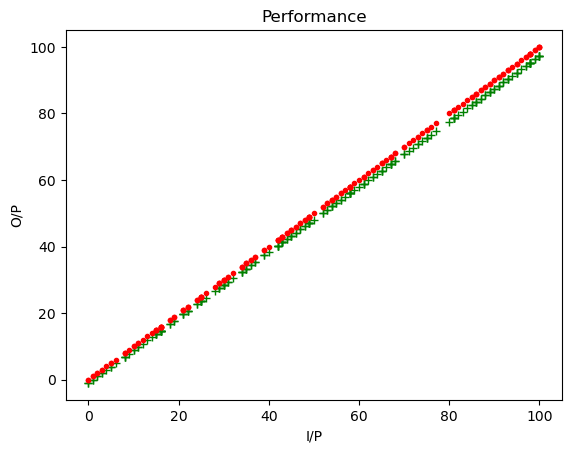

In [121]:
plt.plot(test_ip,test_predictions,"+",color="green")
plt.plot(test_ip,test_op,".",color="red")
plt.title("Performance")
plt.xlabel("I/P")
plt.ylabel("O/P")
plt.show()

### Cost

In [134]:
from sklearn.metrics import mean_squared_error

cost=mean_squared_error(test_op,test_predictions)
cost

3.86293884076201